In [1]:
from Functions import *

# Heading

Hilbert space structure $\mathcal{H}_S\otimes\mathcal{H}_L\otimes\mathcal{H}_B\otimes \mathcal{H}_{M_H}\otimes \mathcal{H}_{M_C}$

Hamiltonian:

Free
$$
\begin{aligned}
H_0= & H_s+H_l+H_b \\
H_s= & e_s\left(|1\rangle\langle 1| \otimes I_{d_l} \otimes I_2 \otimes I_2 \otimes I_2\right) \\
H_l= & \sum_{n=0}^{d_l-3} e_l n\left(I_2 \otimes|n\rangle\langle n| \otimes I_2 \otimes I_2 \otimes I_2\right) \\
& +\left(e_l\left(d_l-1\right)-e_s\right)\left(I_2 \otimes\left|d_l-2\right\rangle\left\langle d_l-2\right| \otimes I_2 \otimes I_2 \otimes I_2\right) \\
& +e_l\left(d_l-1\right)\left(I_2 \otimes\left|d_l-1\right\rangle\left\langle d_l-1\right| \otimes I_2 \otimes I_2 \otimes I_2\right) \\
H_b= & e_l\left(I_2 \otimes I_{d_l} \otimes|1\rangle\langle 1| \otimes I_2 \otimes I_2\right)
\end{aligned}
$$

$$
\begin{aligned}
H_{\text {machine }} & =H_{M H}+H_{M C} \\
H_{M H} & =e_h\left(I_2 \otimes I_2 \otimes I_2 \otimes|1\rangle\langle 1| \otimes I_2\right) \\
H_{M C} & =e_c\left(I_2 \otimes I_2 \otimes I_2 \otimes I_2 \otimes|1\rangle\langle 1|\right)
\end{aligned}
$$

Interaction
$$
\begin{aligned}
H_I= & H_{s l}+H_{l b}+H_{m l}+H_{s l}^{\dagger}+H_{l b}^{\dagger}+H_{m l}^{\dagger} \\
H_{s l}= & g_{s l}\left(|1\rangle\left\langle 0|\otimes| d_l-2\right\rangle\left\langle d_l-1\right| \otimes I_2 \otimes I_2 \otimes I_2\right) \\
H_{l b}= & g_{l b}\left(I_2 \otimes \sum_{n=1}^{d_l-3}|n-1\rangle\langle n|\otimes| 1\rangle\langle 0| \otimes I_2 \otimes I_2\right) \\
& +g_{l b}\left(I_2 \otimes\left|d_l-3\right\rangle\left\langle d_l-1|\otimes| 1\right\rangle\langle 0| \otimes I_2 \otimes I_2\right) \\
H_{m l}= & g_{m l}\left(I_2 \otimes\left|d_l-2\right\rangle\left\langle 0\left|\otimes I_2 \otimes\right| 0\right\rangle\langle 1|\otimes| 1\rangle\langle 0|\right)
\end{aligned}
$$

In [9]:
from Functions import *
def H0(e_s,e_l,d_l):
    H_s= tensor(e_s*matrix_element(1,1,2),identity(d_l),identity(2),identity(2),identity(2)) # system
    H_l= tensor(identity(2),Qobj(np.sum([e_l*n*matrix_element(n,n,d_l).full() for n in range(0,d_l-2)],axis=0)),identity(2),identity(2),identity(2)) #levels until d_l-2
    H_l+= tensor(identity(2),(e_l*(d_l-1)-e_s)*matrix_element(d_l-2,d_l-2,d_l),identity(2),identity(2),identity(2))  #smaller gap at (e_l*(d_l-1)-e_s) energy
    H_l+= tensor(identity(2),e_l*(d_l-1)*matrix_element(d_l-1,d_l-1,d_l),identity(2),identity(2),identity(2)) # final gap at e_l*(d_l-1)
    H_b = tensor(identity(2),identity(d_l),e_l*matrix_element(1,1,2),identity(2),identity(2))
    Hout=H_s+H_l+H_b
    return(Hout.to(core.data.CSR))

def HI(g_sl,g_lb,g_ml,d_l):
    H_sl= g_sl*tensor(matrix_element(1,0,2),matrix_element(d_l-2,d_l-1,d_l),identity(2),identity(2),identity(2)) # system-ladder interaction
    H_lb= g_lb*tensor(identity(2),Qobj(np.sum([matrix_element(n-1,n,d_l).full() for n in range(1,d_l-2)],axis=0)),matrix_element(1,0,2),identity(2),identity(2)) # ladder-bath interaction starting from first level below smaller gap, ie d_l-3
    H_lb+=g_lb*tensor(identity(2),matrix_element(d_l-3,d_l-1,d_l),matrix_element(1,0,2),identity(2),identity(2)) #   ladder-bath interaction from d_l-1 to d_l-3 jumping the second level which has the wrong gap for this interaction
    H_ml= g_ml*tensor(identity(2),matrix_element(d_l-2,0,d_l),identity(2),matrix_element(0,1,2),matrix_element(1,0,2))
    HI_0=H_sl+H_lb+H_ml
    Hout=HI_0+HI_0.dag()
    return(Hout.to(core.data.CSR))

def H_machine_0(e_c,e_h,d_l):
    H_MH= tensor(identity(2),identity(d_l),identity(2),e_h*matrix_element(1,1,2),identity(2)) # hot machine
    H_MC= tensor(identity(2),identity(d_l),identity(2),identity(2),e_c*matrix_element(1,1,2)) # cold machine
    Hout=H_MH+H_MC
    return(Hout.to(core.data.CSR))

def c_MH_pl(r,Rbeta,d_l):
    return(tensor(identity(2),identity(d_l),identity(2),np.sqrt(r*Rbeta)*matrix_element(1,0,2),identity(2)))

def c_MH_mi(r,Rbeta,d_l):
    return(tensor(identity(2),identity(d_l),identity(2),np.sqrt(r*Rbeta)*matrix_element(0,1,2),identity(2)))

def c_MC_pl(r,Rbeta,d_l):
    return(tensor(identity(2),identity(d_l),identity(2),identity(2),np.sqrt(r*Rbeta)*matrix_element(1,0,2)))

def c_MC_mi(r,Rbeta,d_l):
    return(tensor(identity(2),identity(d_l),identity(2),identity(2),np.sqrt(r*Rbeta)*matrix_element(0,1,2)))

def c_bath_mi(r,Rbeta,d_l):
    return(tensor(identity(2),identity(d_l),np.sqrt(r*Rbeta)* matrix_element(0,1,2),identity(2),identity(2)))

def c_bath_pl(r,Rbeta,d_l):
    return(tensor(identity(2),identity(d_l),np.sqrt(r*Rbeta)* matrix_element(1,0,2),identity(2),identity(2)))


# c_l_plus = tensor(identity(2),c_l * Qobj(np.sum([matrix_element(n+1,n,d_l ).full() for n in range(0,d_l-2)],axis=0)),identity(2))
# c_sys_plus = tensor(c_s *matrix_element(1,0,2),identity(d_l),identity(2))
# c_bath_minus = tensor(identity(2),identity(d_l),c_b* matrix_element(0,1,2))

/tmp/ipykernel_12440/2035231777.py:68: RuntimeWarning: invalid value encountered in sqrt
  plt.fill_between(real_times, result.expect[0]- np.sqrt(result.expect[4]-result.expect[0]**2)/2,  result.expect[0] + np.sqrt(result.expect[4]-result.expect[0]**2)/2, color='gray', alpha=0.5, label='Current +- sdt dev /2')


d_l,g_sl,g_lb,g_ml,e_s,e_l,e_C,e_H,rH,rC,rB,betaH,betaC,betaB
[4, 1, 1, 1, 0.3, 1, 0.8, 2.5, 1, 1, 1, 0.1, 312.8125, 312.8125]
virtual inverse temperature:  -147.05882352941177
efficiency:  0.68


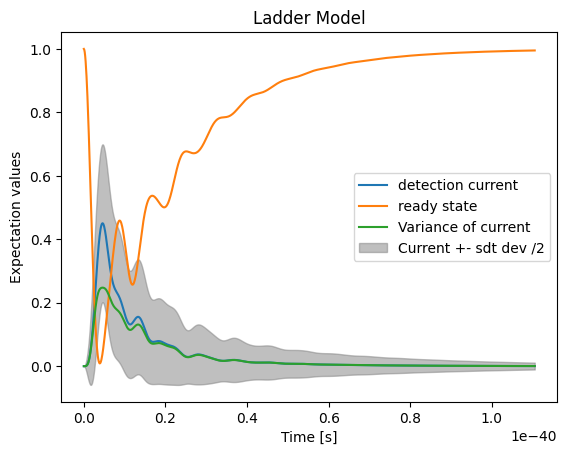

In [11]:
d_l=4

# Interaction strenghts
g_sl=1
g_lb=1
g_ml=1

# Energies
#e_l=1/(d_l-3)
e_l=1
e_s=0.3 *e_l
e_C=0.8 * e_l
e_H=e_l*(d_l-2)-e_s+e_C #subtracting 1 e_s from the max gap and then adding a e_C to be resonant with the 10(d-1) <-> 010 transition

t_f = 50 #final time
t_steps = 1000 # num of timesteps

# Jump rates
rH=1
rC=1
rB=1

DelBeta=100
betaH=0.1
betaC=e_H/e_C *(betaH  + DelBeta)
betaB=betaC
RbetaH_pl=np.exp(-betaH*e_H)/(1+np.exp(-betaH*e_H))
RbetaH_mi=1/(1+np.exp(-betaH*e_H))
RbetaC_pl=np.exp(-betaC*e_C)/(1+np.exp(-betaC*e_C))
RbetaC_mi=1/(1+np.exp(-betaC*e_C))
RbetaB_pl=np.exp(-betaB*e_l)/(1+np.exp(-betaB*e_l))
RbetaB_mi=1/(1+np.exp(-betaB*e_l))

virtualtemp=(e_H-e_C)/(e_H*betaH-e_C *betaC)
betaV=1/virtualtemp
efficiency= (1-betaH/betaC)*(1+1/(virtualtemp*betaC-1))

parameters=[d_l,g_sl,g_lb,g_ml,e_s,e_l,e_C,e_H,rH,rC,rB,betaH,betaC,betaB]
tag_parameters="d_l,g_sl,g_lb,g_ml,e_s,e_l,e_C,e_H,rH,rC,rB,betaH,betaC,betaB"
# Total Hamiltonian
H=H0(e_s,e_l,d_l)+HI(g_sl,g_lb,g_ml,d_l)+H_machine_0(e_C,e_H,d_l)

# Jump operators
c_ops=[c_MH_pl(rH,RbetaH_pl,d_l),c_MH_mi(rH,RbetaH_mi,d_l),c_MC_pl(rC,RbetaC_pl,d_l),c_MC_mi(rC,RbetaC_mi,d_l),c_bath_mi(rB,RbetaB_mi,d_l),c_bath_pl(rB,RbetaB_pl,d_l)]

# Observable operators
e_current=e_l*(c_bath_pl(rB,RbetaB_pl,d_l).dag()*c_bath_pl(rB,RbetaB_pl,d_l)-c_bath_mi(rB,RbetaB_mi,d_l).dag()*c_bath_mi(rB,RbetaB_mi,d_l))
e_machine_heat_dissip =e_C*(c_MC_pl(rC,RbetaC_pl,d_l).dag()*c_MC_pl(rC,RbetaC_pl,d_l)-c_MC_mi(rC,RbetaC_mi,d_l).dag()*c_MC_mi(rC,RbetaC_mi,d_l))
e_machine_heat_draw =e_H*(c_MH_pl(rH,RbetaH_pl,d_l).dag()*c_MH_pl(rH,RbetaH_pl,d_l)-c_MH_mi(rH,RbetaH_mi,d_l).dag()*c_MH_mi(rH,RbetaH_mi,d_l))
e_ready=tensor(identity(2),matrix_element(d_l-2,d_l-2,d_l),identity(2),identity(2),identity(2))
e_ops=[-e_current,e_ready,-e_machine_heat_dissip,-e_machine_heat_draw,e_current.dag()*e_current]

# e_op_bath_current=c_b

# [tensor(identity(2),identity(d_l),matrix_element(1,1,2)),tensor(identity(2),matrix_element(d_l-2,d_l-2,d_l),identity(2)),tensor(identity(2),Qobj(np.sum([matrix_element(n,n,d_l).full() for n in range(0,d_l-2)],axis=0)),identity(2)),tensor(matrix_element(1,1,2),identity(d_l),identity(2)),c_bath_mi.dag()*c_bath_mi]
steady_prev_run=steadystate(H,c_ops)
psi0 = tensor(matrix_element(1,1,2),ptrace(steady_prev_run,1),ptrace(steady_prev_run,2),ptrace(steady_prev_run,3),ptrace(steady_prev_run,4))
times = np.linspace(0., t_f, t_steps)
hbar=6.62607015*10**(-34)
real_times=times*6.62607015*10**(-34)/(299792458)
result = mesolve(H,psi0, tlist=times,c_ops=c_ops, e_ops=e_ops)
result2=result
fig, ax = plt.subplots()
plt.plot(real_times,result.expect[0],label="detection current")
plt.plot(real_times,result.expect[1],label="ready state")
# plt.plot(real_times,result.expect[2]*betaC,label="Machine entropy production")
plt.plot(real_times,result.expect[4]-result.expect[0]**2,label="Variance of current")
plt.fill_between(real_times, result.expect[0]- np.sqrt(result.expect[4]-result.expect[0]**2)/2,  result.expect[0] + np.sqrt(result.expect[4]-result.expect[0]**2)/2, color='gray', alpha=0.5, label='Current +- sdt dev /2')

#plt.plot(real_times,result.expect[3],label="Machine heat draw")
#plt.plot(times[200:300],result.expect[0][200:300])
#plt.plot(times[200:300],result.expect[1][200:300])
# plt.plot(times,result.expect[2])
# plt.plot(times,result.expect[3])
# plt.plot(result.expect[4])
ax.set_xlabel('Time [s]')
ax.set_ylabel('Expectation values')
ax.legend()
plt.title("Ladder Model")
print(tag_parameters)
print(parameters)
print("virtual inverse temperature: ",betaV)
print("efficiency: ",efficiency)
# fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/detector.eps', format='eps')

There is a problem with this model, namely that it only produces a thermal state between the levels $|0\rangle$ and $|d-2\rangle$. However, at finite temperatures, this means that keeping the machine in the steady state requires no additional entropy production, as both these level don't couple to the bath and are thus stable.

In the following we should look at a machine as they use it in the Erker clock to drive the ladder up level by level.

**The Variance above is not what we call noise, this needs to be done properly!!**

# Erker clock type approach of driving

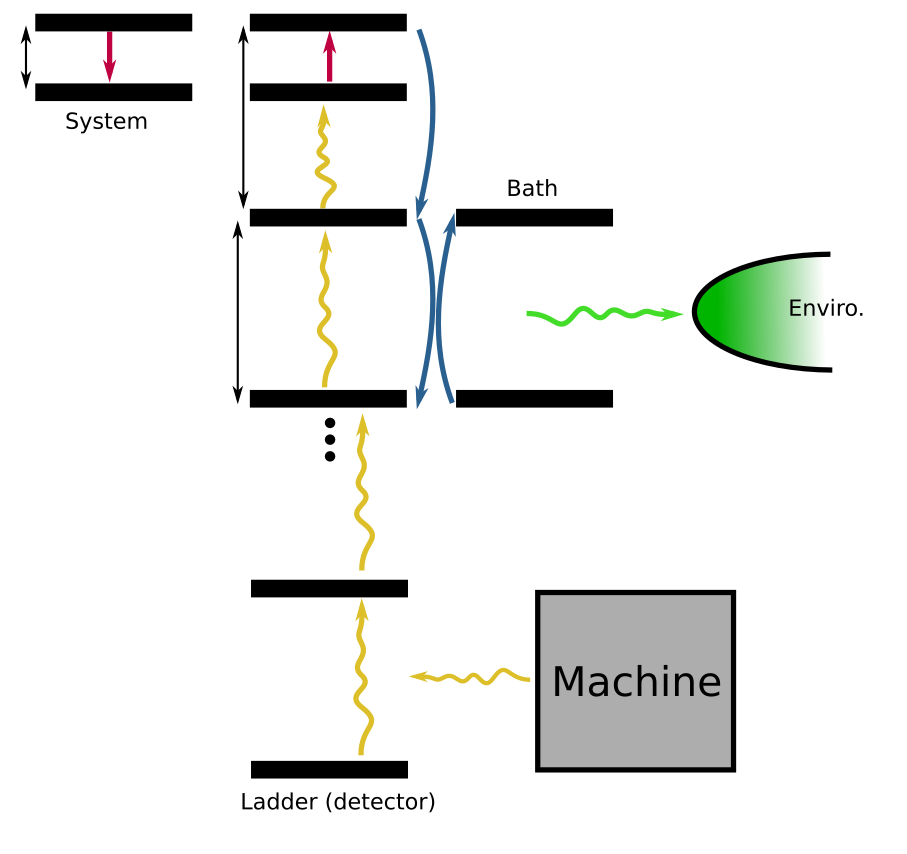

## Exact solution

In [4]:
from Functions import *
def H0_full(e_s,e_l,d_l):
    H_s= tensor(e_s*matrix_element(1,1,2),identity(d_l),identity(2),identity(2),identity(2),identity(2)) # system
    H_l= tensor(identity(2),Qobj(np.sum([e_l*n*matrix_element(n,n,d_l).full() for n in range(0,d_l-2)],axis=0)),identity(2),identity(2),identity(2),identity(2)) #levels until d_l-2
    H_l+= tensor(identity(2),(e_l*(d_l-1)-e_s)*matrix_element(d_l-2,d_l-2,d_l),identity(2),identity(2),identity(2),identity(2))  #smaller gap at (e_l*(d_l-1)-e_s) energy
    H_l+= tensor(identity(2),e_l*(d_l-1)*matrix_element(d_l-1,d_l-1,d_l),identity(2),identity(2),identity(2),identity(2)) # final gap at e_l*(d_l-1)
    H_b = tensor(identity(2),identity(d_l),e_l*matrix_element(1,1,2),identity(2),identity(2),identity(2))
    Hout=H_s+H_l+H_b
    return(Hout.to(core.data.CSR))

def HI_full(g_sl,g_lb,g_ml,d_l):
    H_sl= g_sl*tensor(matrix_element(1,0,2),matrix_element(d_l-2,d_l-1,d_l),identity(2),identity(2),identity(2),identity(2)) # system-ladder interaction
    H_lb= g_lb*tensor(identity(2),Qobj(np.sum([matrix_element(n-1,n,d_l).full() for n in range(1,d_l-2)],axis=0)),matrix_element(1,0,2),identity(2),identity(2),identity(2)) # ladder-bath interaction starting from first level below smaller gap, ie d_l-3
    H_lb+=g_lb*tensor(identity(2),matrix_element(d_l-3,d_l-1,d_l),matrix_element(1,0,2),identity(2),identity(2),identity(2)) #   ladder-bath interaction from d_l-1 to d_l-3 jumping the second level which has the wrong gap for this interaction
    H_ml= g_ml*tensor(identity(2),Qobj(np.sum([matrix_element(n+1,n,d_l).full() for n in range(0,d_l-2)],axis=0)),identity(2),matrix_element(0,1,2),matrix_element(1,0,2),identity(2))
    H_ml+= g_ml*tensor(identity(2),matrix_element(d_l-2,d_l-3,d_l),identity(2),matrix_element(0,1,2),identity(2),matrix_element(1,0,2))
    HI_0=H_sl+H_lb+H_ml
    HI_0=HI_0+HI_0.dag()
    return(HI_0.to(core.data.CSR))

def H_machine_0_full(e_s,e_c,e_h,d_l):
    H_MH= tensor(identity(2),identity(d_l),identity(2),e_h*matrix_element(1,1,2),identity(2),identity(2)) # hot machine
    H_MC= tensor(identity(2),identity(d_l),identity(2),identity(2),e_c*matrix_element(1,1,2),identity(2)) # cold machine
    H_MC_2= tensor(identity(2),identity(d_l),identity(2),identity(2),identity(2),(e_h-e_c-e_s)*matrix_element(1,1,2)) # cold machine smaler gap e_l=e_h-e_c ... e_l-e_s is the gap from d-3 to d-2
    Hout=H_MH+H_MC+H_MC_2
    return(Hout.to(core.data.CSR))

def c_MH_pl_full(r,Rbeta,d_l):
    return(tensor(identity(2),identity(d_l),identity(2),np.sqrt(r*Rbeta)*matrix_element(1,0,2),identity(2),identity(2)))

def c_MH_mi_full(r,Rbeta,d_l):
    return(tensor(identity(2),identity(d_l),identity(2),np.sqrt(r*Rbeta)*matrix_element(0,1,2),identity(2),identity(2)))

def c_MC_pl_full(r,Rbeta,d_l):
    return(tensor(identity(2),identity(d_l),identity(2),identity(2),np.sqrt(r*Rbeta)*matrix_element(1,0,2),identity(2)))

def c_MC_mi_full(r,Rbeta,d_l):
    return(tensor(identity(2),identity(d_l),identity(2),identity(2),np.sqrt(r*Rbeta)*matrix_element(0,1,2),identity(2)))

def c_MC2_pl_full(r,Rbeta,d_l):
    return(tensor(identity(2),identity(d_l),identity(2),identity(2),identity(2),np.sqrt(r*Rbeta)*matrix_element(1,0,2)))

def c_MC2_mi_full(r,Rbeta,d_l):
    return(tensor(identity(2),identity(d_l),identity(2),identity(2),identity(2),np.sqrt(r*Rbeta)*matrix_element(0,1,2)))

def c_bath_mi_full(r,Rbeta,d_l):
    return(tensor(identity(2),identity(d_l),np.sqrt(r*Rbeta)* matrix_element(0,1,2),identity(2),identity(2),identity(2)))

def c_bath_pl_full(r,Rbeta,d_l):
    return(tensor(identity(2),identity(d_l),np.sqrt(r*Rbeta)* matrix_element(1,0,2),identity(2),identity(2),identity(2)))


d_l,g_sl,g_lb,g_ml,e_s,e_l,e_C,e_H,rH,rC,rB,betaH,betaC,betaB
[4, 1, 1, 1, 0.3, 1, 0.8, 1.8, 1, 1, 1, 0.0, 10.0, 10.0]
virtual inverse temperature:  -8.0
efficiency:  0.5555555555555556


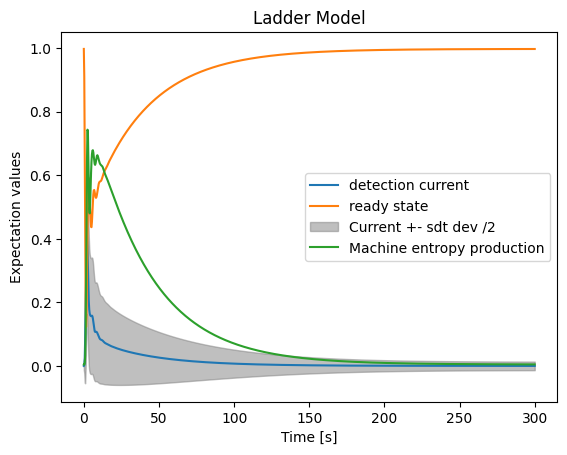

In [158]:
d_l=4

# Interaction strenghts
g_sl=1
g_lb=1
g_ml=1

# Energies
#e_l=1/(d_l-3)
e_l=1
e_s=0.3 *e_l
e_C=0.8 * e_l
e_H=e_l+e_C
t_f = 300 #final time
t_steps = 1000 # num of timesteps

# Jump rates
rH=1
rC=1
rB=1

DelBeta=10
betaH=0.0
betaC=e_H/e_C *(betaH  )+ DelBeta
betaB=betaC
RbetaH_pl=np.exp(-betaH*e_H)/(1+np.exp(-betaH*e_H))
RbetaH_mi=1/(1+np.exp(-betaH*e_H))
RbetaC_pl=np.exp(-betaC*e_C)/(1+np.exp(-betaC*e_C))
RbetaC_mi=1/(1+np.exp(-betaC*e_C))
RbetaB_pl=np.exp(-betaB*e_l)/(1+np.exp(-betaB*e_l))
RbetaB_mi=1/(1+np.exp(-betaB*e_l))

virtualtemp=(e_H-e_C)/(e_H*betaH-e_C *betaC)
betaV=1/virtualtemp
efficiency= (1-betaH/betaC)*(1+1/(virtualtemp*betaC-1))

parameters=[d_l,g_sl,g_lb,g_ml,e_s,e_l,e_C,e_H,rH,rC,rB,betaH,betaC,betaB]
tag_parameters="d_l,g_sl,g_lb,g_ml,e_s,e_l,e_C,e_H,rH,rC,rB,betaH,betaC,betaB"
# Total Hamiltonian
H=H0_full(e_s,e_l,d_l)+HI_full(g_sl,g_lb,g_ml,d_l)+H_machine_0_full(e_s,e_C,e_H,d_l)

# Jump operators
c_ops=[c_MH_pl_full(rH,RbetaH_pl,d_l),c_MH_mi_full(rH,RbetaH_mi,d_l),c_MC_pl_full(rC,RbetaC_pl,d_l),c_MC_mi_full(rC,RbetaC_mi,d_l),c_MC2_pl_full(rC,RbetaC_pl,d_l),c_MC2_mi_full(rC,RbetaC_mi,d_l),c_bath_mi_full(rB,RbetaB_mi,d_l),c_bath_pl_full(rB,RbetaB_pl,d_l)]

# Observable operators
e_current=e_l*(c_bath_pl_full(rB,RbetaB_pl,d_l).dag()*c_bath_pl_full(rB,RbetaB_pl,d_l)-c_bath_mi_full(rB,RbetaB_mi,d_l).dag()*c_bath_mi_full(rB,RbetaB_mi,d_l))
e_machine_heat_dissip =e_C*(c_MC_pl_full(rC,RbetaC_pl,d_l).dag()*c_MC_pl_full(rC,RbetaC_pl,d_l)-c_MC_mi_full(rC,RbetaC_mi,d_l).dag()*c_MC_mi_full(rC,RbetaC_mi,d_l))
e_machine_heat_draw =e_H*(c_MH_pl_full(rH,RbetaH_pl,d_l).dag()*c_MH_pl_full(rH,RbetaH_pl,d_l)-c_MH_mi_full(rH,RbetaH_mi,d_l).dag()*c_MH_mi_full(rH,RbetaH_mi,d_l))
e_ready=tensor(identity(2),matrix_element(d_l-2,d_l-2,d_l),identity(2),identity(2),identity(2),identity(2))
e_ops=[-e_current,e_ready,-e_machine_heat_dissip,-e_machine_heat_draw,e_current.dag()*e_current]

# [tensor(identity(2),identity(d_l),matrix_element(1,1,2)),tensor(identity(2),matrix_element(d_l-2,d_l-2,d_l),identity(2)),tensor(identity(2),Qobj(np.sum([matrix_element(n,n,d_l).full() for n in range(0,d_l-2)],axis=0)),identity(2)),tensor(matrix_element(1,1,2),identity(d_l),identity(2)),c_bath_mi.dag()*c_bath_mi]
steady_prev_run=steadystate(H,c_ops)
psi0 = tensor(matrix_element(1,1,2),ptrace(steady_prev_run,1),ptrace(steady_prev_run,2),ptrace(steady_prev_run,3),ptrace(steady_prev_run,4),ptrace(steady_prev_run,5))
times = np.linspace(0., t_f, t_steps)
hbar=6.62607015*10**(-34)
real_times=times*6.62607015*10**(-34)/(299792458)
result = mesolve(H,psi0, tlist=times,c_ops=c_ops, e_ops=e_ops)

fig, ax = plt.subplots()
plt.plot(times,result.expect[0],label="detection current")
plt.plot(times,result.expect[1],label="ready state")
plt.fill_between(times, result.expect[0]- np.sqrt(result.expect[4]-result.expect[0]**2)/2,  result.expect[0] + np.sqrt(result.expect[4]-result.expect[0]**2)/2, color='gray', alpha=0.5, label='Current +- sdt dev /2')

plt.plot(times,result.expect[2]*betaC/1,label="Machine entropy production")
#plt.plot(times,result.expect[3],label="Machine heat draw")
#plt.plot(times[200:300],result.expect[0][200:300])
#plt.plot(times[200:300],result.expect[1][200:300])
# plt.plot(times,result.expect[2])
# plt.plot(times,result.expect[3])
# plt.plot(result.expect[4])
ax.set_xlabel('Time [s]')
ax.set_ylabel('Expectation values')
ax.legend(("detection current", "ready state","Machine entropy production", "Machine heat draw"))
plt.title("Ladder Model")
print(tag_parameters)
print(parameters)
print("virtual inverse temperature: ",betaV)
print("efficiency: ",efficiency)
ax.legend()
# fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/detector.eps', format='eps')

## Two point correlation function

In [ ]:
d_l=4

# Interaction strenghts
g_sl=1
g_lb=1
g_ml=1

# Energies
#e_l=1/(d_l-3)
e_l=1
e_s=0.3 *e_l
e_C=0.8 * e_l
e_H=e_l+e_C
t_f = 300 #final time
t_steps = 1000 # num of timesteps

# Jump rates
rH=1
rC=1
rB=1

DelBeta=10
betaH=0.0
betaC=e_H/e_C *(betaH  )+ DelBeta
betaB=betaC
RbetaH_pl=np.exp(-betaH*e_H)/(1+np.exp(-betaH*e_H))
RbetaH_mi=1/(1+np.exp(-betaH*e_H))
RbetaC_pl=np.exp(-betaC*e_C)/(1+np.exp(-betaC*e_C))
RbetaC_mi=1/(1+np.exp(-betaC*e_C))
RbetaB_pl=np.exp(-betaB*e_l)/(1+np.exp(-betaB*e_l))
RbetaB_mi=1/(1+np.exp(-betaB*e_l))

virtualtemp=(e_H-e_C)/(e_H*betaH-e_C *betaC)
betaV=1/virtualtemp
efficiency= (1-betaH/betaC)*(1+1/(virtualtemp*betaC-1))

parameters=[d_l,g_sl,g_lb,g_ml,e_s,e_l,e_C,e_H,rH,rC,rB,betaH,betaC,betaB]
tag_parameters="d_l,g_sl,g_lb,g_ml,e_s,e_l,e_C,e_H,rH,rC,rB,betaH,betaC,betaB"
# Total Hamiltonian
H=H0_full(e_s,e_l,d_l)+HI_full(g_sl,g_lb,g_ml,d_l)+H_machine_0_full(e_s,e_C,e_H,d_l)

# Jump operators
c_ops=[c_MH_pl_full(rH,RbetaH_pl,d_l),c_MH_mi_full(rH,RbetaH_mi,d_l),c_MC_pl_full(rC,RbetaC_pl,d_l),c_MC_mi_full(rC,RbetaC_mi,d_l),c_MC2_pl_full(rC,RbetaC_pl,d_l),c_MC2_mi_full(rC,RbetaC_mi,d_l),c_bath_mi_full(rB,RbetaB_mi,d_l),c_bath_pl_full(rB,RbetaB_pl,d_l)]

# Observable operators
e_current=e_l*(c_bath_pl_full(rB,RbetaB_pl,d_l).dag()*c_bath_pl_full(rB,RbetaB_pl,d_l)-c_bath_mi_full(rB,RbetaB_mi,d_l).dag()*c_bath_mi_full(rB,RbetaB_mi,d_l))
e_machine_heat_dissip =e_C*(c_MC_pl_full(rC,RbetaC_pl,d_l).dag()*c_MC_pl_full(rC,RbetaC_pl,d_l)-c_MC_mi_full(rC,RbetaC_mi,d_l).dag()*c_MC_mi_full(rC,RbetaC_mi,d_l))
e_machine_heat_draw =e_H*(c_MH_pl_full(rH,RbetaH_pl,d_l).dag()*c_MH_pl_full(rH,RbetaH_pl,d_l)-c_MH_mi_full(rH,RbetaH_mi,d_l).dag()*c_MH_mi_full(rH,RbetaH_mi,d_l))
e_ready=tensor(identity(2),matrix_element(d_l-2,d_l-2,d_l),identity(2),identity(2),identity(2),identity(2))
e_ops=[-e_current,e_ready,-e_machine_heat_dissip,-e_machine_heat_draw,e_current.dag()*e_current]

# [tensor(identity(2),identity(d_l),matrix_element(1,1,2)),tensor(identity(2),matrix_element(d_l-2,d_l-2,d_l),identity(2)),tensor(identity(2),Qobj(np.sum([matrix_element(n,n,d_l).full() for n in range(0,d_l-2)],axis=0)),identity(2)),tensor(matrix_element(1,1,2),identity(d_l),identity(2)),c_bath_mi.dag()*c_bath_mi]
steady_prev_run=steadystate(H,c_ops)
psi0 = tensor(matrix_element(1,1,2),ptrace(steady_prev_run,1),ptrace(steady_prev_run,2),ptrace(steady_prev_run,3),ptrace(steady_prev_run,4),ptrace(steady_prev_run,5))
times = np.linspace(0., t_f, t_steps)
hbar=6.62607015*10**(-34)


corr = qutip.correlation_2op_2t(H, psi0, np.linspace(10,10,1), times, c_ops,e_ops[0],e_ops[0])

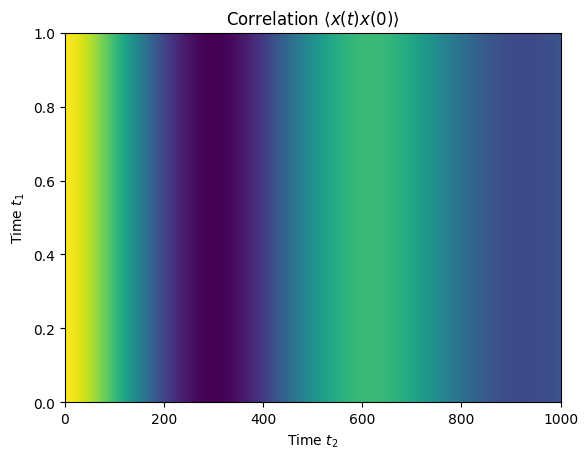

In [187]:
import numpy as np
import matplotlib.pyplot as plt
import qutip


t_f=10
times = np.linspace(0, t_f, 1000)
a = qutip.destroy(10)
x = a.dag() + a
H = a.dag() * a
alpha = 2.5
rho0 = qutip.coherent_dm(10, alpha)
noise=[]
for t in times:
    corr = qutip.correlation_2op_2t(H, rho0, np.linspace(t,t,1), times, [np.sqrt(0.25) * a], x, x)
    noise.append(np.trapz(np.real(corr)[0,:],times))



plt.pcolor(np.real(corr))
plt.xlabel(r'Time $t_2$')
plt.ylabel(r'Time $t_1$')
plt.title(r'Correlation $\left<x(t)x(0)\right>$')
plt.show()

In [184]:
np.trapz(np.real(corr)[0,:],times)

-0.015556663145773086

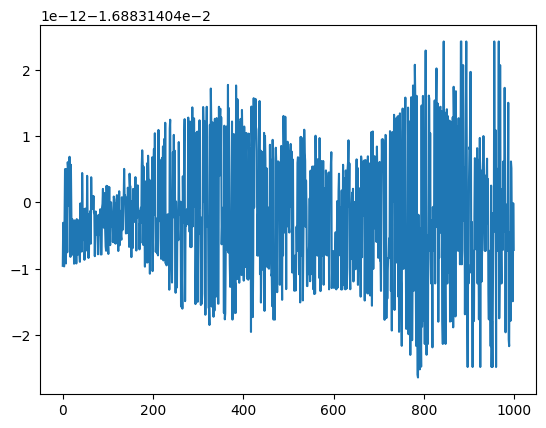

In [188]:
plt.plot(noise)

In [183]:
corr[0,:]

array([ 21.11011561+0.00000000e+00j,  20.95144855+5.08493453e-02j,
        20.7413772 +1.00934314e-01j,  20.48107821+1.50136824e-01j,
        20.17184188+1.98342521e-01j,  19.8150671 +2.45441019e-01j,
        19.41225644+2.91326130e-01j,  18.96501102+3.35896086e-01j,
        18.47502516+3.79053737e-01j,  17.94408097+4.20706747e-01j,
        17.37404265+4.60767766e-01j,  16.76685075+4.99154591e-01j,
        16.12451628+5.35790311e-01j,  15.44911465+5.70603438e-01j,
        14.74277966+6.03528019e-01j,  14.00769726+6.34503737e-01j,
        13.24609938+6.63475996e-01j,  12.46025763+6.90395982e-01j,
        11.65247706+7.15220725e-01j,  10.82508981+7.37913126e-01j,
         9.98044891+7.58441984e-01j,   9.12092194+7.76782001e-01j,
         8.24888487+7.92913772e-01j,   7.36671587+8.06823760e-01j,
         6.47678926+8.18504259e-01j,   5.58146946+8.27953339e-01j,
         4.68310513+8.35174782e-01j,   3.78402337+8.40177997e-01j,
         2.88652404+8.42977929e-01j,   1.99287428+8.43594949e-

## Montecarlo calculation for fluctuations

In [136]:

d_l=4

# Interaction strenghts
g_sl=1
g_lb=1
g_ml=1

# Energies
#e_l=1/(d_l-3)
e_l=1
e_s=0.3 *e_l
e_C=0.8 * e_l
e_H=e_l+e_C
t_f = 100 #final time
t_steps = 1000 # num of timesteps

# Jump rates
rH=1
rC=1
rB=1

DelBeta=10000
betaH=0.0
betaC=e_H/e_C *(betaH  )+ DelBeta
betaB=betaC
RbetaH_pl=np.exp(-betaH*e_H)/(1+np.exp(-betaH*e_H))
RbetaH_mi=1/(1+np.exp(-betaH*e_H))
RbetaC_pl=np.exp(-betaC*e_C)/(1+np.exp(-betaC*e_C))
RbetaC_mi=1/(1+np.exp(-betaC*e_C))
RbetaB_pl=np.exp(-betaB*e_l)/(1+np.exp(-betaB*e_l))
RbetaB_mi=1/(1+np.exp(-betaB*e_l))

virtualtemp=(e_H-e_C)/(e_H*betaH-e_C *betaC)
betaV=1/virtualtemp
efficiency= (1-betaH/betaC)*(1+1/(virtualtemp*betaC-1))

ntraj=10000

parameters=[d_l,g_sl,g_lb,g_ml,e_s,e_l,e_C,e_H,rH,rC,rB,betaH,betaC,betaB,t_f,t_steps,ntraj]
tag_parameters="d_l,g_sl,g_lb,g_ml,e_s,e_l,e_C,e_H,rH,rC,rB,betaH,betaC,betaB,t_f,t_"
# Total Hamiltonian
H=H0_full(e_s,e_l,d_l)+HI_full(g_sl,g_lb,g_ml,d_l)+H_machine_0_full(e_s,e_C,e_H,d_l)

# Jump operators
c_ops=[c_MH_pl_full(rH,RbetaH_pl,d_l),c_MH_mi_full(rH,RbetaH_mi,d_l),c_MC_pl_full(rC,RbetaC_pl,d_l),c_MC_mi_full(rC,RbetaC_mi,d_l),c_MC2_pl_full(rC,RbetaC_pl,d_l),c_MC2_mi_full(rC,RbetaC_mi,d_l),c_bath_mi_full(rB,RbetaB_mi,d_l),c_bath_pl_full(rB,RbetaB_pl,d_l)]

# Observable operators
e_current=e_l*(c_bath_pl_full(rB,RbetaB_pl,d_l).dag()*c_bath_pl_full(rB,RbetaB_pl,d_l)-c_bath_mi_full(rB,RbetaB_mi,d_l).dag()*c_bath_mi_full(rB,RbetaB_mi,d_l))
e_machine_heat_dissip =e_C*(c_MC_pl_full(rC,RbetaC_pl,d_l).dag()*c_MC_pl_full(rC,RbetaC_pl,d_l)-c_MC_mi_full(rC,RbetaC_mi,d_l).dag()*c_MC_mi_full(rC,RbetaC_mi,d_l))
e_machine_heat_draw =e_H*(c_MH_pl_full(rH,RbetaH_pl,d_l).dag()*c_MH_pl_full(rH,RbetaH_pl,d_l)-c_MH_mi_full(rH,RbetaH_mi,d_l).dag()*c_MH_mi_full(rH,RbetaH_mi,d_l))
e_ready=tensor(identity(2),matrix_element(d_l-2,d_l-2,d_l),identity(2),identity(2),identity(2),identity(2))
e_ops=[-e_current,e_ready,-e_machine_heat_dissip,-e_machine_heat_draw]

# steady_prev_run=steadystate(H,c_ops)
psi0 = tensor(basis(2,1),basis(d_l,d_l-2),basis(2,0),basis(2,1),basis(2,0),basis(2,0))
#psi0 = tensor(matrix_element(1,1,2),ptrace(steady_prev_run,1),ptrace(steady_prev_run,2),ptrace(steady_prev_run,3),ptrace(steady_prev_run,4),ptrace(steady_prev_run,5))
times = np.linspace(0., t_f, t_steps)
hbar=6.62607015*10**(-34)
real_times=times*6.62607015*10**(-34)/(299792458)

mc_data = mcsolve(H, psi0, times,e_ops=e_ops,c_ops=c_ops, ntraj=ntraj,options={"improved_sampling":True,"map": "parallel"}) # run montecarlo method


## Saving the data
import pickle

def get_var_names_and_values(var_list):
    # Return a dictionary with variable names and values based on object identity
    return {k: v for k, v in globals().items() if any(v is item for item in var_list)}


name_value_dict=get_var_names_and_values(parameters)
parameterstring=",".join([f"{name}={value}" for name, value in name_value_dict.items()])

with open('./Montecarlo_results/mcsolve_result_parameters_'+parameterstring+'.pkl', 'wb') as file:
    pickle.dump(mc_data, file)


10.0%. Run time:  86.33s. Est. time left: 00:00:12:56
20.0%. Run time: 178.62s. Est. time left: 00:00:11:54
30.0%. Run time: 271.34s. Est. time left: 00:00:10:33
40.0%. Run time: 364.67s. Est. time left: 00:00:09:06
50.0%. Run time: 458.01s. Est. time left: 00:00:07:37
60.0%. Run time: 555.34s. Est. time left: 00:00:06:10
70.0%. Run time: 663.15s. Est. time left: 00:00:04:44
80.0%. Run time: 762.93s. Est. time left: 00:00:03:10
90.0%. Run time: 869.32s. Est. time left: 00:00:01:36
100.0%. Run time: 972.73s. Est. time left: 00:00:00:00
Total run time: 972.79s


##### Loading the MC file

In [35]:
import pickle
with open('./Montecarlo_results/mcsolve_result_parameters_'+parameterstring+'.pkl', 'rb') as file:
    mc_data = pickle.load(file)

# Verify that the object is loaded by accessing some attributes
print(f"Times: {mc_data.times}")
print("number of traj:", len(mc_data.col_which))


Times: [0.0, 0.1001001001001001, 0.2002002002002002, 0.3003003003003003, 0.4004004004004004, 0.5005005005005005, 0.6006006006006006, 0.7007007007007008, 0.8008008008008008, 0.9009009009009009, 1.001001001001001, 1.1011011011011012, 1.2012012012012012, 1.3013013013013013, 1.4014014014014016, 1.5015015015015016, 1.6016016016016017, 1.7017017017017018, 1.8018018018018018, 1.9019019019019021, 2.002002002002002, 2.1021021021021022, 2.2022022022022023, 2.3023023023023024, 2.4024024024024024, 2.5025025025025025, 2.6026026026026026, 2.702702702702703, 2.802802802802803, 2.902902902902903, 3.0030030030030033, 3.1031031031031033, 3.2032032032032034, 3.3033033033033035, 3.4034034034034035, 3.5035035035035036, 3.6036036036036037, 3.7037037037037037, 3.8038038038038042, 3.9039039039039043, 4.004004004004004, 4.104104104104104, 4.2042042042042045, 4.3043043043043046, 4.404404404404405, 4.504504504504505, 4.604604604604605, 4.704704704704705, 4.804804804804805, 4.904904904904905, 5.005005005005005, 5

In [110]:


import pickle
with open('./Montecarlo_results/mcsolve_result_parametersd_l=10,g_sl=1,g_lb=1,g_ml=1,e_l=1,e_s=0.3,e_C=0.8,e_H=1.8,t_f=100,t_steps=1000,rH=1,rC=1,rB=1,betaH=0.0,betaC=10000.0,betaB=10000.0.pkl', 'rb') as file:
    mc_data = pickle.load(file)

# Verify that the object is loaded by accessing some attributes
print(f"Times: {mc_data.times}")
print("number of traj:", len(mc_data.col_which))

Times: [0.0, 0.1001001001001001, 0.2002002002002002, 0.3003003003003003, 0.4004004004004004, 0.5005005005005005, 0.6006006006006006, 0.7007007007007008, 0.8008008008008008, 0.9009009009009009, 1.001001001001001, 1.1011011011011012, 1.2012012012012012, 1.3013013013013013, 1.4014014014014016, 1.5015015015015016, 1.6016016016016017, 1.7017017017017018, 1.8018018018018018, 1.9019019019019021, 2.002002002002002, 2.1021021021021022, 2.2022022022022023, 2.3023023023023024, 2.4024024024024024, 2.5025025025025025, 2.6026026026026026, 2.702702702702703, 2.802802802802803, 2.902902902902903, 3.0030030030030033, 3.1031031031031033, 3.2032032032032034, 3.3033033033033035, 3.4034034034034035, 3.5035035035035036, 3.6036036036036037, 3.7037037037037037, 3.8038038038038042, 3.9039039039039043, 4.004004004004004, 4.104104104104104, 4.2042042042042045, 4.3043043043043046, 4.404404404404405, 4.504504504504505, 4.604604604604605, 4.704704704704705, 4.804804804804805, 4.904904904904905, 5.005005005005005, 5

##### Rest

In [38]:
def find_duplicates(arr):
    duplicates = []
    seen = set()

    for item in arr:
        if item in seen:
            duplicates.append(item)
        else:
            seen.add(item)

    return duplicates

find_duplicates(all_times)

NameError: name 'all_times' is not defined

In [137]:
import numpy as np


def cumulative_jumps(mc_data, jump_ind_pl, jump_ind_mi):
    # Precompute and store cumulative differences for all columns
    cumulative_full = [
        np.cumsum((np.array(col) == 1).astype(int)) - np.cumsum(col == jump_ind_mi)
        for col in mc_data.col_which
    ]
    return cumulative_full

def get_cumulative_values_at_time(lists, target_time, col_times):
    # Use numpy for fast computation
    return [
        lst[col_times[i] <= target_time][-1] if np.any(col_times[i] <= target_time) else 0
        for i, lst in enumerate(lists)
    ]

def variance_from_mc_data(mc_data, jump_ind_pl, jump_ind_mi, times):
    cumulative_full = cumulative_jumps(mc_data, jump_ind_pl, jump_ind_mi)
    return np.array([
        (t, np.var(get_cumulative_values_at_time(cumulative_full, t, mc_data.col_times)))
        for t in times
    ])

# def varianceOfvariance_from_mc_data(mc_data, jump_ind_pl, jump_ind_mi, times):
#     return variance_from_mc_data(mc_data, jump_ind_pl, jump_ind_mi, times)

def average_from_mc_data(mc_data, jump_ind_pl, jump_ind_mi, times):
    cumulative_full = cumulative_jumps(mc_data, jump_ind_pl, jump_ind_mi)
    return np.array([
        (t, np.mean(get_cumulative_values_at_time(cumulative_full, t, mc_data.col_times)))
        for t in times
    ])


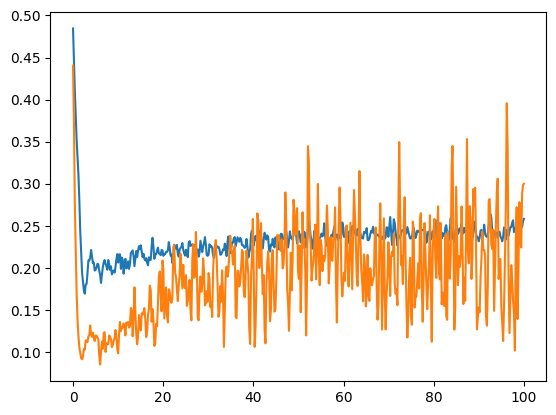

In [140]:
lst=average_from_mc_data(mc_data,6,7,np.linspace(0,100,500))
lst2=variance_from_mc_data(mc_data,6,7,np.linspace(0,100,500))
plt.plot(lst[:,0],np.gradient(lst[:,1],lst[:,0]))
plt.plot(lst2[:,0],np.gradient(lst2[:,1],lst[:,0]))

d_l=4,g_sl=1,g_lb=1,g_ml=1,e_l=1,e_s=0.3,e_C=0.8,e_H=1.8,t_f=100,t_steps=1000,rH=1,rC=1,rB=1,betaH=0.0,betaC=10000.0,betaB=10000.0,ntraj=10000


Text(0.5, 1.0, 'Detection current and fluctuations')

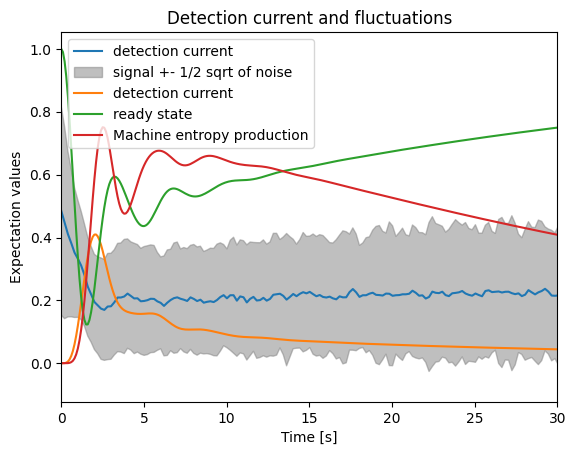

In [151]:
fig, ax=plt.subplots()
print(parameterstring)
plt.plot(lst[:,0],np.gradient(lst[:,1],lst[:,0]),label="detection current")
plt.fill_between(lst[:,0], np.gradient(lst[:,1],lst[:,0]) - np.sqrt(np.gradient(lst2[:,1],lst[:,0]))/2,  np.gradient(lst[:,1],lst[:,0]) + np.sqrt(np.gradient(lst2[:,1],lst[:,0]))/2, color='gray', alpha=0.5, label='signal +- 1/2 sqrt of noise ')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Expectation values')
plt.plot(times,result.expect[0],label="detection current")
plt.plot(times,result.expect[1],label="ready state")

plt.plot(times,result.expect[2]*betaC/1000,label="Machine entropy production")
ax.legend()
ax.set_xlim([0,30])
plt.title("Detection current and fluctuations")

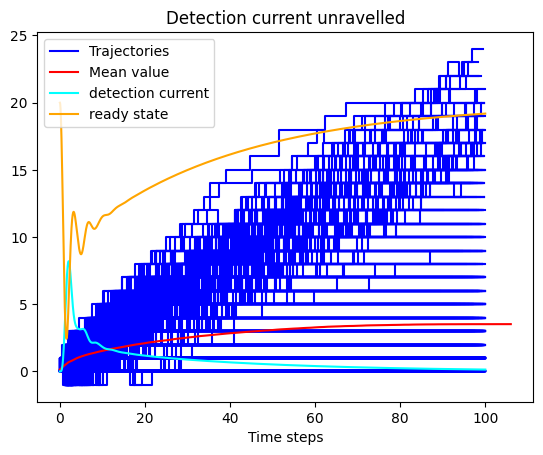

In [8]:
fig, ax = plt.subplots()

# Plot the trajectories with step function
for n in range(len(mc_data.col_which)):
    plt.step(mc_data.col_times[n],
             np.cumsum(mc_data.col_which[n]==6) - np.cumsum(mc_data.col_which[n]==5),
             color="blue",
             label="Trajectories" if n == 0 else "")  # Label only the first trajectory for the legend





# Plot the mean value
plt.plot(np.mean(np.array([np.cumsum(padded_lists[n]==6)-np.cumsum(padded_lists[n]==5) for n in range(len(mc_data.col_which))]), axis=0),
         color="red",
         label="Mean value")

# Plot the variance
# noise_out=np.gradient(np.var(np.array([np.cumsum(padded_lists[n]==6)-np.cumsum(padded_lists[n]==5) for n in range(len(mc_data.col_which))]), axis=0),times)
# plt.plot(noise_out,
#          color="green",
#          label="Variance")

# plt.plot(np.linspace(0,t_f,4000),result.expect[0]*20,color="cyan",label="detection current")
# plt.plot(np.linspace(0,t_f,4000),result.expect[1]*20,color="orange",label="ready state")

# Set the title and labels
plt.title("Detection current unravelled")
ax.set_xlabel('Time steps')

# Display the legend
ax.legend()

plt.show()


/tmp/ipykernel_6863/1559653258.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap= cm.get_cmap('Blues', len(data.col_which))


<Figure size 640x480 with 0 Axes>

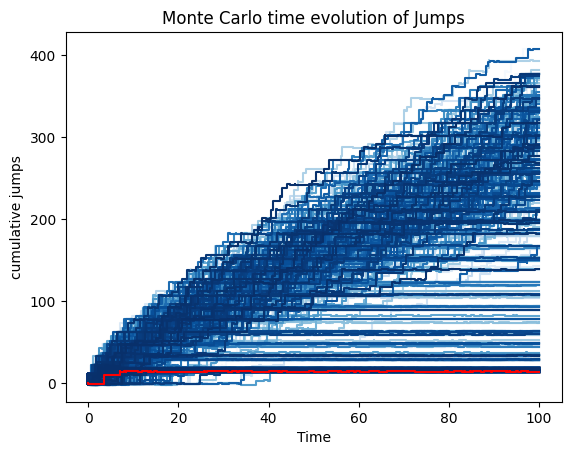

In [173]:
def make_trajectory_plottable(data,jump,t_f): #also outputs the reshaped trajectories such that the span the whole x axis (stay constant if no jump occurs) .. jump indicates the jump channel index
   traj=[]
   cmap= cm.get_cmap('Blues', len(data.col_which))
   for i in range(0,len(data.col_which)):
      color=cmap(i)
      col_which_mi=np.concatenate([[0],np.cumsum(np.array(data.col_which[i])==jump)])
      col_which_pl=np.concatenate([[0],np.cumsum(np.array(data.col_which[i])==jump+1)])
      col_which_0=np.concatenate([col_which_0,[col_which_0[-1]]])
      col_times_0=np.concatenate([[0],data.col_times[i],[t_f]])
      traj.append([col_times_0,col_which_0])
      plt.step(col_times_0,col_which_0,color=color)
   return(traj)

plt.figure()
fig, ax = plt.subplots()
traj=make_trajectory_plottable(mc_data,100)

i=20
col_which_0=np.concatenate([[0],np.cumsum(np.array(mc_data.col_which[i])*2-1)])
col_which_0=np.concatenate([col_which_0,[col_which_0[-1]]])
col_times_0=np.concatenate([[0],mc_data.col_times[i],[t_f]])
plt.step(col_times_0,col_which_0,color="red")

# plt.step(data.col_times,np.cumsum(np.array(data.col_which)*2-1),color="red")
plt.title('Monte Carlo time evolution of Jumps')
plt.autoscale()
plt.xlabel('Time')

# vari=statistics.variance([sublist[1][-1] for sublist in traj])/t_f #the sublist thing selects only the last elements of the cumulative jump count, ie at the last timestep
# curr= statistics.mean([np.sum(sublist*2-1)/t_f for sublist in data.col_which])
# dyn_act= statistics.mean([np.sum((sublist*2-1)**2)/t_f for sublist in data.col_which])
# statistics.mean[statistics.mean([subsublist[1] for subsublist in sublist])]
plt.ylabel('cumulative jumps')

plt.show()
#fig.savefig('/home/manu/Mcplot.eps', format='eps')